# AA-UTE 2026

## P7.3 - Detección de anomalías con DARTS

Este práctico presenta la detección de anomalías basado en **forecasting** con la biblioteca `darts`.  
La idea: se entrena un modelo de pronóstico sobre el comportamiento normal y luego se usa el error de predicción como score de anomalía.

Se muestra en el notebook el ejemplo con los datos de Taxis de NY  
https://unit8co.github.io/darts/examples/22-anomaly-detection-examples.html#Anomaly-Model:-Taxi-passengers-in-NY


### Trabajo a realizar

Este notebook está pensado para ejecutar las celdas en orden y revisar cómo cambia la detección al cambiar el modelo de forecasting, la ventana temporal y el umbral de score.

Al final se propone realizar detección de anomalías sobre datos propios.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hack para ADTK-----------
plt.style.library['seaborn-whitegrid'] = plt.style.library['seaborn-v0_8-whitegrid']  
# Fix the missing attribute by mapping iteritems to items
pd.Series.iteritems = pd.Series.items
pd.DataFrame.iteritems = pd.DataFrame.items
#---------------------------

from darts import TimeSeries
from darts.ad import (
    ForecastingAnomalyModel,
    KMeansScorer,
    NormScorer,
    WassersteinScorer,
)
from darts.ad.utils import (
    eval_metric_from_scores,
    show_anomalies_from_scores,
)
from darts.dataprocessing.transformers import Scaler
from darts.datasets import TaxiNewYorkDataset
from darts.metrics import mae, rmse
from darts.models import SKLearnModel


warnings.filterwarnings("ignore")
np.random.seed(42)

#plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (14, 4)

%matplotlib widget

## Parte 1. Carga de datos

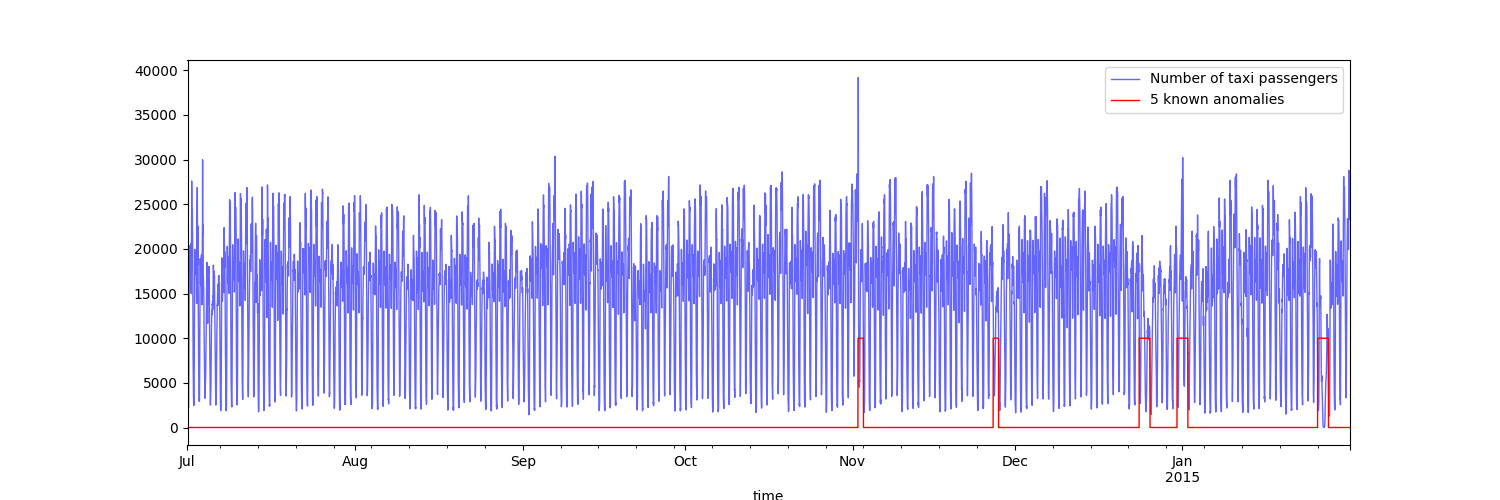

In [2]:
# load the data
series_taxi = TaxiNewYorkDataset().load()

# define start and end dates for some known anomalies
anomalies_day = {
    "NYC Marathon": ("2014-11-02 00:00", "2014-11-02 23:30"),
    "Thanksgiving ": ("2014-11-27 00:00", "2014-11-27 23:30"),
    "Christmas": ("2014-12-24 00:00", "2014-12-25 23:30"),
    "New Years": ("2014-12-31 00:00", "2015-01-01 23:30"),
    "Snow Blizzard": ("2015-01-26 00:00", "2015-01-27 23:30"),
}
anomalies_day = {
    k: (pd.Timestamp(v[0]), pd.Timestamp(v[1])) for k, v in anomalies_day.items()
}

# create a series with the binary anomaly flags
anomalies = pd.Series([0] * len(series_taxi), index=series_taxi.time_index)
for start, end in anomalies_day.values():
    anomalies.loc[(start <= anomalies.index) & (anomalies.index <= end)] = 1.0

series_taxi_anomalies = TimeSeries.from_series(anomalies)

# plot the data and the anomalies
fig, ax = plt.subplots(figsize=(15, 5))
series_taxi.plot(label="Number of taxi passengers", linewidth=1, color="#6464ff")
(series_taxi_anomalies * 10000).plot(label="5 known anomalies", color="r", linewidth=1)
plt.show()

## Parte 2. Definir un modelo de Forecasting

In [3]:
# split the data in a training and testing set
s_taxi_train = series_taxi[:4500]
s_taxi_test = series_taxi[4500:]

# Add covariates (hour and day of the week)
add_encoders = {
    "cyclic": {"future": ["hour", "dayofweek"]},
}

# one week corresponds to (7 days * 24 hours * 2) of 30 minutes
one_week = 7 * 24 * 2

forecasting_model = SKLearnModel(
    lags=one_week,
    #lags_future_covariates=[0],
    output_chunk_length=1,
    add_encoders=add_encoders,
)
forecasting_model.fit(s_taxi_train)

Specified future encoders in `add_encoders` at model creation but model does not accept future covariates. future encoders will be ignored.


SKLearnModel(lags=336, lags_past_covariates=None, lags_future_covariates=None, output_chunk_length=1, output_chunk_shift=0, add_encoders={'cyclic': {'future': ['hour', 'dayofweek']}}, model=None, multi_models=True, use_static_covariates=True, random_state=None)

## Parte 3. Crear un ForecastingAnomalyModel y entrenar
Compuesto por el Forcaster definido en la parte 2 y Scorers

In [4]:
# with timestamps of 30 minutes
half_a_day = 2 * 12
full_day = 2 * 24

# instantiate the anomaly model with: one fitted model, and 3 scorers
anomaly_model = ForecastingAnomalyModel(
    model=forecasting_model,
    scorer=[
        NormScorer(ord=1),
        WassersteinScorer(window=half_a_day, window_agg=False),
        WassersteinScorer(window=full_day, window_agg=True),
    ],
)

Entrenar el modelo de Detección de Anomalías

In [5]:
# start:  Indica en qué punto de la serie se empieza a entrenar el modelo de detección de anomalías. 
#         En este caso, en el 10% del conjunto de train 
# allow_model_training: Lo ponemos en false porque ya se entrenó previamente el modelo de forecasting.

START = 0.1
anomaly_model.fit(s_taxi_train, start=START, allow_model_training=False, verbose=True)

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

## Parte 4. Metricas y visualización

In [6]:
anomaly_scores, model_forecasting = anomaly_model.score(
    s_taxi_test, start=START, return_model_prediction=True, verbose=True
)
pred_start = model_forecasting.start_time()

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

On testing set -> MAE: 591.56633262643, RMSE: 891.3842715949629


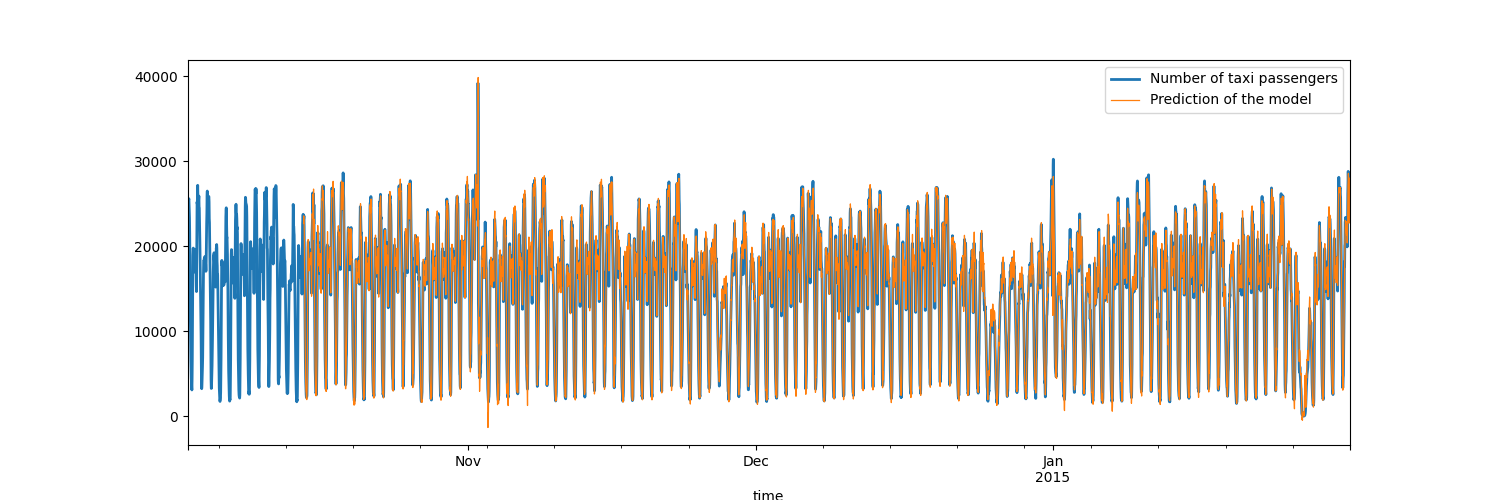

In [7]:
# compute the MAE and RMSE on the test set
print(
    f"On testing set -> MAE: {mae(model_forecasting, s_taxi_test)}, RMSE: {rmse(model_forecasting, s_taxi_test)}"
)

# plot the data and the anomalies
fig, ax = plt.subplots(figsize=(15, 5))
s_taxi_test.plot(label="Number of taxi passengers")
model_forecasting.plot(label="Prediction of the model", linewidth=0.9)
plt.show()

In [8]:
metric_names = ["AUC_ROC", "AUC_PR"]
metric_data = []
for metric_name in metric_names:
    metric_data.append(
        anomaly_model.eval_metric(
            anomalies=series_taxi_anomalies,
            series=s_taxi_test,
            start=START,
            metric=metric_name,
        )
    )
pd.DataFrame(data=metric_data, index=metric_names).T

,AUC_ROC,AUC_PR
Norm (ord=1)_w=1,0.633747,0.196764
WassersteinScorer_w=24,0.840603,0.571452
WassersteinScorer_w=48,0.938210,0.666160


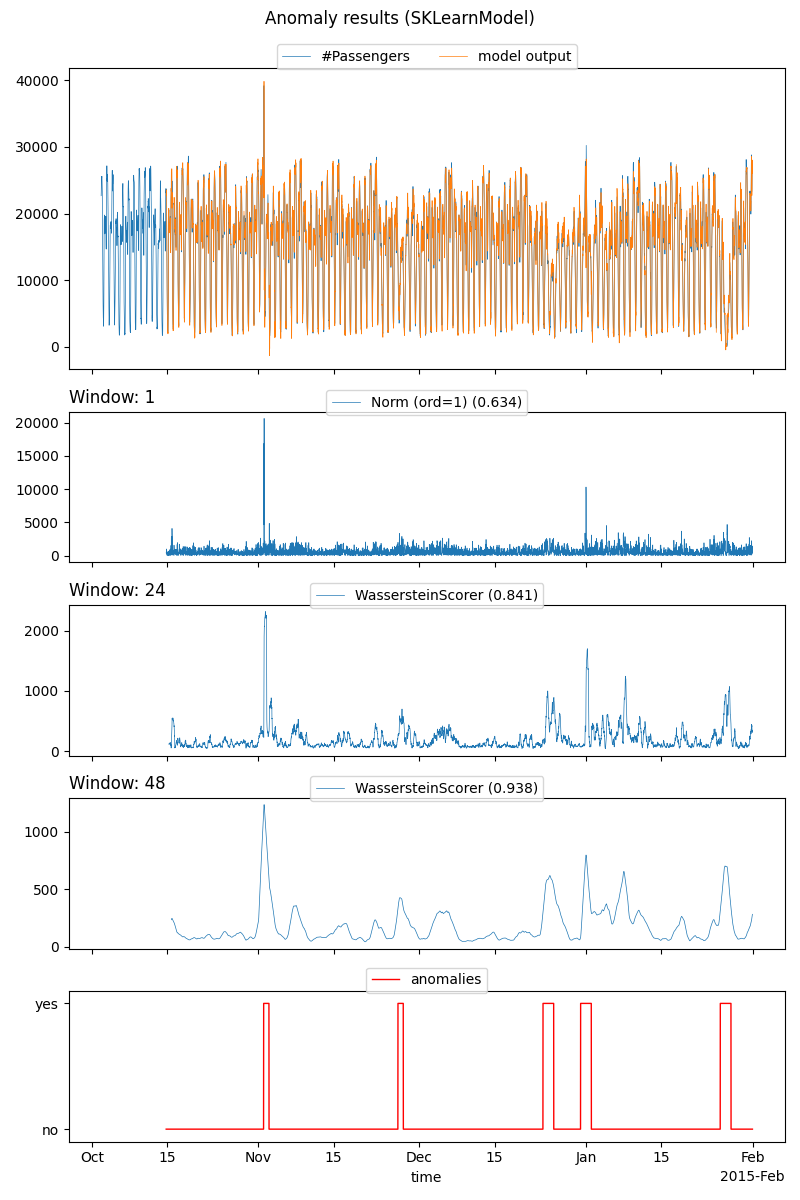

In [9]:
anomaly_model.show_anomalies(
    series=s_taxi_test,
    anomalies=series_taxi_anomalies[pred_start:],
    start=START,
    metric="AUC_ROC",
)

## Parte 5. Pasar de Scores a Anomalías con un Detector 

In [10]:
from darts.ad.detectors import QuantileDetector,  ThresholdDetector

contamination = 0.95
detector = QuantileDetector(high_quantile=contamination)

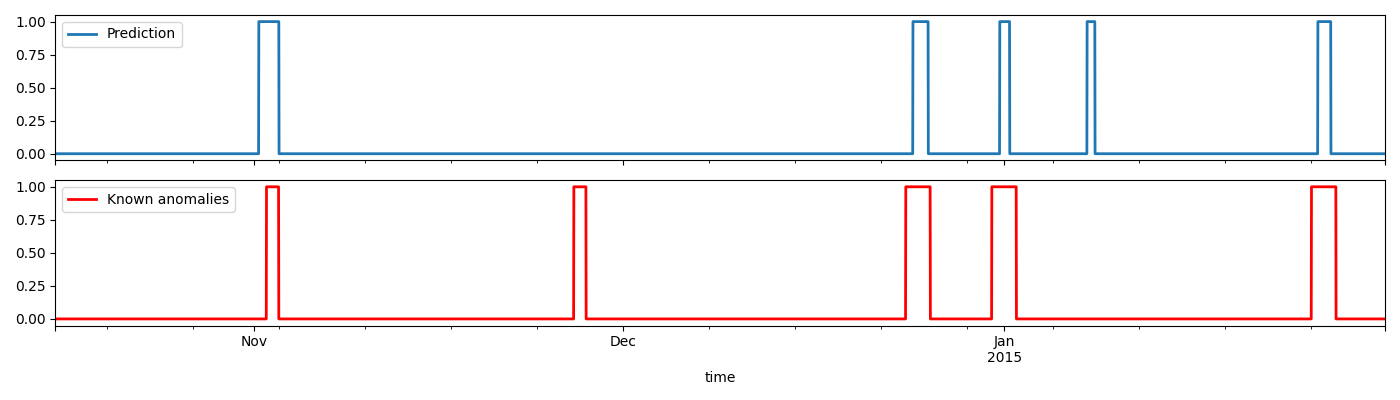

In [11]:
# use the anomaly score that gave the best AUC ROC score: Wasserstein anomaly score with a window of 'full_day'
best_anomaly_score = anomaly_scores[-1]

# fit and detect on the anomaly scores, it will return a binary prediction
anomaly_pred = detector.fit_detect(series=best_anomaly_score)

# plot the binary prediction
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)
anomaly_pred.plot(label="Prediction", ax=ax1)
series_taxi_anomalies[anomaly_pred.start_time() :].plot(
    label="Known anomalies", ax=ax2, color="red"
)
fig.tight_layout()

In [12]:
for metric_name in ["accuracy", "precision", "recall", "f1"]:
    metric_val = detector.eval_metric(
        pred_scores=best_anomaly_score,
        anomalies=series_taxi_anomalies,
        window=full_day,
        metric=metric_name,
    )
    print(metric_name + f": {metric_val:.2f}/1")

accuracy: 0.91/1
precision: 0.77/1
recall: 0.32/1
f1: 0.45/1


## Parte 6. Para experimentar
* Repetir la detección de anomalías con datos propios.  


In [13]:
# TODO

## Parte 7.  Probar algunos de los ejemplos de ADTK

https://adtk.readthedocs.io/en/stable/examples.html

In [14]:
df = series_taxi.to_dataframe(copy=True)

In [15]:
# TODO

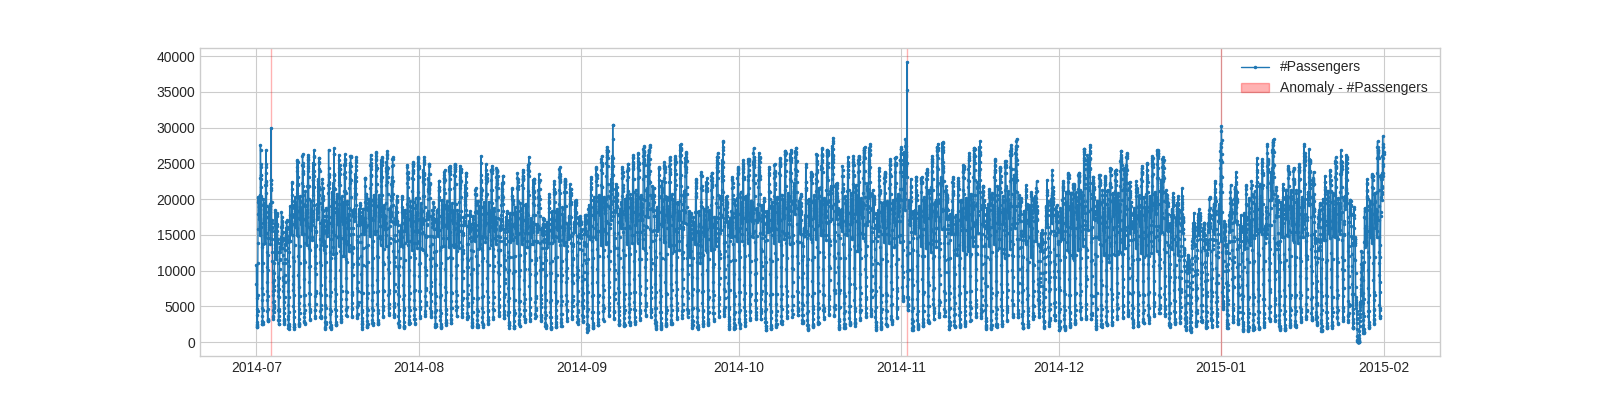

In [16]:
from adtk.detector import PersistAD
from adtk.visualization import plot
persist_ad = PersistAD(c=3.0, side='positive')
anomalies = persist_ad.fit_detect(df)
plot(df, anomaly=anomalies, ts_linewidth=1, ts_markersize=3, anomaly_color='red');

